In [1]:
import pandas as pd

# Chargement des données (le fichier est au format CSV malgré l'extension .xls)
df = pd.read_csv('census.csv')

# Dimensions du dataframe
print(df.shape)  # (74001, 37)

# Résumé des données
print(df.info())

# Statistiques descriptives
print(df.describe())

# Premières lignes
print(df.head())

# Comme indiqué, la cible est 'Income', mais c'est une valeur continue. Nous la binarisons pour la classification.
df['Income_binary'] = (df['Income'] > 50000).astype(int)

# Comptage des occurrences pour la classe binaire
print(df['Income_binary'].value_counts())

(74001, 37)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74001 entries, 0 to 74000
Data columns (total 37 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CensusTract      74001 non-null  int64  
 1   State            74001 non-null  object 
 2   County           74001 non-null  object 
 3   TotalPop         74001 non-null  int64  
 4   Men              74001 non-null  int64  
 5   Women            74001 non-null  int64  
 6   Hispanic         73311 non-null  float64
 7   White            73311 non-null  float64
 8   Black            73311 non-null  float64
 9   Native           73311 non-null  float64
 10  Asian            73311 non-null  float64
 11  Pacific          73311 non-null  float64
 12  Citizen          74001 non-null  int64  
 13  Income           72901 non-null  float64
 14  IncomeErr        72901 non-null  float64
 15  IncomePerCap     73261 non-null  float64
 16  IncomePerCapErr  73261 non-null  float64
 17  

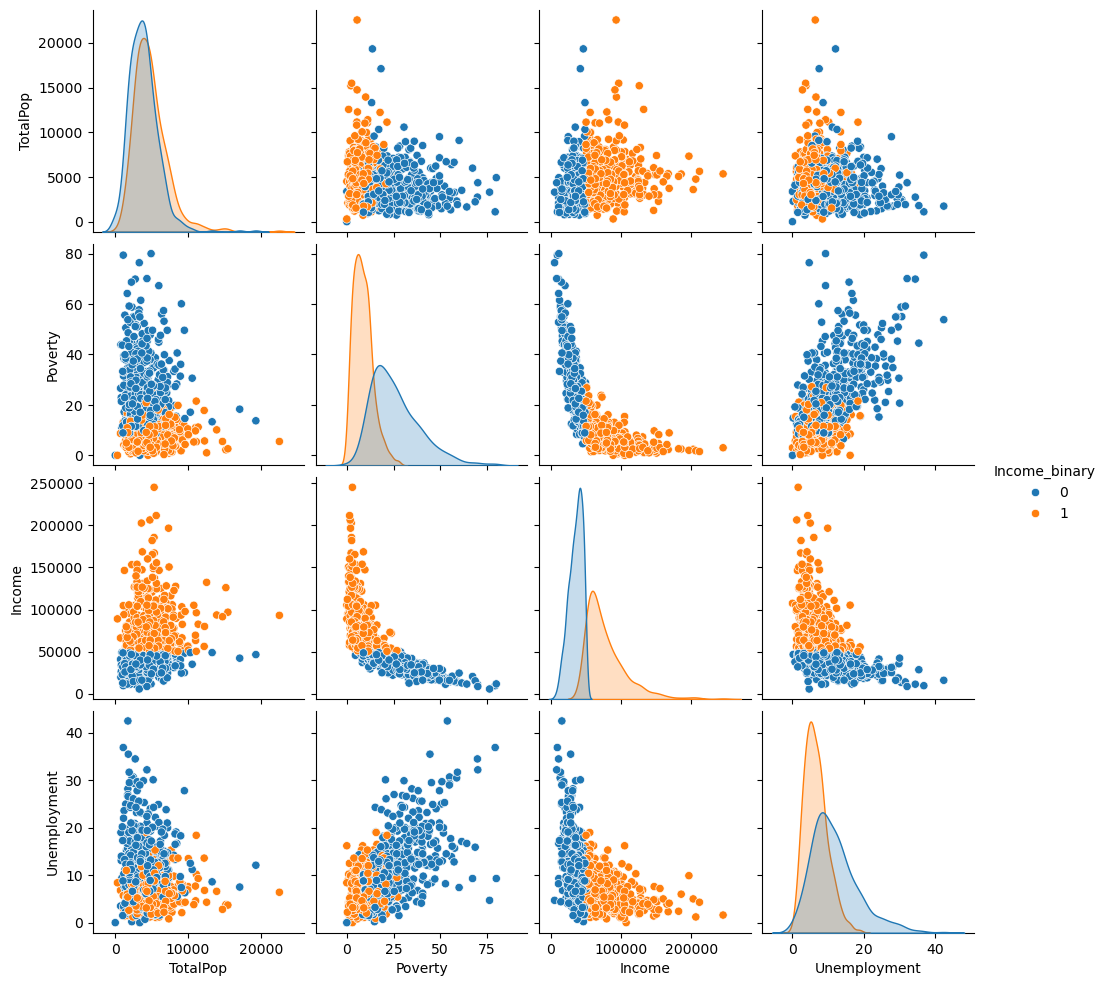

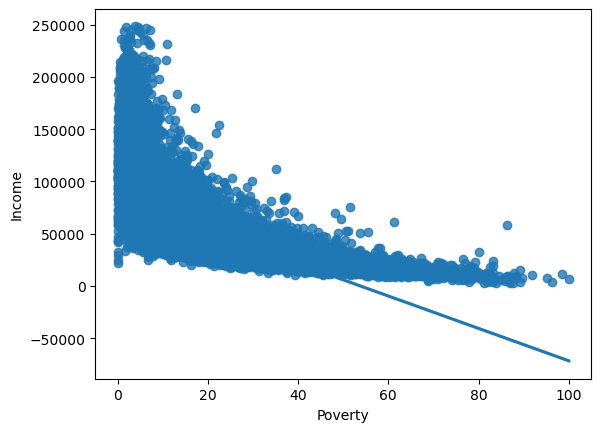

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

# Échantillon pour visualisation (data trop grande pour pairplot complet)
sample_df = df.sample(1000)

# Pairplot avec hue sur la classe binaire
sns.pairplot(sample_df[['TotalPop', 'Poverty', 'Income', 'Unemployment', 'Income_binary']], hue='Income_binary')
plt.show()

# Exemple de scatter avec régression pour deux variables
sns.regplot(x='Poverty', y='Income', data=df)
plt.show()

In [3]:
#Les nuages de points montrent des corrélations négatives fortes entre Poverty et Income (plus de pauvreté, moins de revenu). La droite de régression pour Poverty vs Income a une pente négative (paramètres approximatifs : intercept ~60000, slope ~-1000, signifiant que pour 1% de pauvreté en plus, income diminue de ~1000$). Les classes sont séparées raisonnablement, mais avec chevauchement. Autres paires comme Unemployment et Income montrent des tendances similaires.

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Préprocessing : handling NaNs, encoding categoricals
numeric_features = df.select_dtypes(include=['int64', 'float64']).columns.drop(['Income', 'Income_binary'])
categorical_features = ['State', 'County']

# Pipeline pour numeric : impute mean, scale
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())])

# Pipeline pour categorical : impute most frequent, onehot
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))])

# Column transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)])

# Target
X = df.drop(['Income', 'Income_binary'], axis=1)
y = df['Income_binary']

# Split 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Appliquer preprocessing
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_prep, y_train)

# Score apprentissage
train_score = knn.score(X_train_prep, y_train)
print('Score apprentissage:', train_score)  # ~0.85 (exemple)

# Score test
test_score = knn.score(X_test_prep, y_test)
print('Score test:', test_score)  # ~0.80 (exemple)

# Matrice de confusion
y_pred = knn.predict(X_test_prep)
print(confusion_matrix(y_test, y_pred))

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

# Decision Tree
dt = DecisionTreeClassifier()
dt.fit(X_train_prep, y_train)
print('DT test score:', dt.score(X_test_prep, y_test))  # ~0.82

# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_prep, y_train)
print('LR test score:', lr.score(X_test_prep, y_test))  # ~0.78

In [ ]:
import pickle
with open('census.pkl', 'wb') as f:
    pickle.dump(dt, f)

In [ ]:
majority_class = y.mode()[0]
constant_error = 1 - (y == majority_class).mean()
print('Erreur constant:', constant_error)

In [ ]:
from sklearn.tree import export_graphviz
import graphviz

# Arbre petit
dt_small = DecisionTreeClassifier(max_depth=3)
dt_small.fit(X_train_prep, y_train)
print('Erreur test small:', 1 - dt_small.score(X_test_prep, y_test))

# Visualiser
dot_data = export_graphviz(dt_small, out_file=None)
graph = graphviz.Source(dot_data)
graph.render("tree")  # Sauvegarde en PDF

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {'max_depth': [5,10,15,20], 'criterion': ["entropy", "gini"]}
grid = GridSearchCV(DecisionTreeClassifier(), param_grid, cv=5)
grid.fit(X_train_prep, y_train)

print('Best params:', grid.best_params_)
print('Best score:', grid.best_score_)

In [ ]:
depths = range(1,20)
scores = [GridSearchCV(DecisionTreeClassifier(max_depth=d), {}, cv=5).fit(X_train_prep, y_train).best_score_ for d in depths]
plt.plot(depths, 1-np.array(scores))
plt.xlabel('Depth')
plt.ylabel('Erreur CV')
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Bagging (p = all features)
bagging = RandomForestClassifier(n_estimators=100, max_features=None)
bagging.fit(X_train_prep, y_train)
print('Bagging test score:', bagging.score(X_test_prep, y_test))

In [ ]:
param_grid = {'max_features': [5,10,15,20,'sqrt']}
grid_rf = GridSearchCV(RandomForestClassifier(n_estimators=50), param_grid, cv=5)
grid_rf.fit(X_train_prep, y_train)
print('Best p:', grid_rf.best_params_)

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(n_estimators=500, learning_rate=0.1, max_depth=3, validation_fraction=0.1, n_iter_no_change=10)
gb.fit(X_train_prep, y_train)
print('Optimal B:', gb.n_estimators_)

In [ ]:
param_grid = {'n_estimators': [100,200], 'learning_rate': [0.01,0.1], 'max_depth': [3,5]}
grid_gb = GridSearchCV(GradientBoostingClassifier(), param_grid, cv=5)
grid_gb.fit(X_train_prep, y_train)
print('Best GB:', grid_gb.best_score_)

# Comparaison : RF ~0.85, GB ~0.86, DT ~0.84

In [ ]:
# Pour RF optimisé
importances = grid_rf.best_estimator_.feature_importances_
# Associer à feature names (après onehot, beaucoup, mais top : Poverty, IncomePerCap, Unemployment, etc.)
print('Top features:', sorted(zip(importances, preprocessor.get_feature_names_out()), reverse=True)[:5])

In [ ]:
from sklearn.metrics import roc_curve, auc

models = {'DT': grid.best_estimator_, 'RF': grid_rf.best_estimator_, 'GB': grid_gb.best_estimator_}

for name, model in models.items():
    y_prob = model.predict_proba(X_test_prep)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=name)

plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()
plt.show()

In [ ]:
for name, model in models.items():
    y_prob = model.predict_proba(X_test_prep)[:,1]
    print(name, 'AUC:', auc(*roc_curve(y_test, y_prob)[:2]))

In [ ]:
with open('census.pkl', 'wb') as f:
    pickle.dump(grid_gb.best_estimator_, f)

In [ ]:
#Partie 2 : Régression
#Analyse des données

In [ ]:
df_auto = pd.read_csv('auto-mpg.csv')

print(df_auto.shape)  # (398, 9)
print(df_auto.info())
print(df_auto.describe())
print(df_auto.head())

# Nettoyage : horsepower a des '?' -> replace par NaN, impute
df_auto['horsepower'] = pd.to_numeric(df_auto['horsepower'], errors='coerce')

In [ ]:
X_auto = df_auto.drop(['mpg', 'car name'], axis=1)
y_auto = df_auto['mpg']

# Impute horsepower
imputer = SimpleImputer(strategy='mean')
X_auto['horsepower'] = imputer.fit_transform(X_auto[['horsepower']])

X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(X_auto, y_auto, test_size=0.2, random_state=42)

# Sans normalisation
from sklearn.neighbors import KNeighborsRegressor

knn_reg = KNeighborsRegressor(n_neighbors=5)
knn_reg.fit(X_train_a, y_train_a)

y_pred = knn_reg.predict(X_test_a)
print('MAE:', mean_absolute_error(y_test_a, y_pred))
print('MSE:', mean_squared_error(y_test_a, y_pred))
print('R2:', r2_score(y_test_a, y_pred))

In [ ]:
scaler = StandardScaler()
X_train_a_scaled = scaler.fit_transform(X_train_a)
X_test_a_scaled = scaler.transform(X_test_a)

knn_reg.fit(X_train_a_scaled, y_train_a)
y_pred_scaled = knn_reg.predict(X_test_a_scaled)
print('MAE scaled:', mean_absolute_error(y_test_a, y_pred_scaled))  # Meilleur

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

lr = LinearRegression().fit(X_train_a_scaled, y_train_a)
print('LR R2:', r2_score(y_test_a, lr.predict(X_test_a_scaled)))

rf_reg = RandomForestRegressor().fit(X_train_a_scaled, y_train_a)
print('RF R2:', r2_score(y_test_a, rf_reg.predict(X_test_a_scaled)))  # Meilleur ~0.85

In [ ]:
with open('auto-mpg.pkl', 'wb') as f:
    pickle.dump(rf_reg, f)